In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

In [11]:
titanic = pd.read_csv("data/titanic.csv")
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,PaCh,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [12]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Name      887 non-null    object 
 3   Sex       887 non-null    object 
 4   Age       887 non-null    float64
 5   SibSp     887 non-null    int64  
 6   PaCh      887 non-null    int64  
 7   Fare      887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [13]:
titanic.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
PaCh        0
Fare        0
dtype: int64

In [14]:
titanic.describe()

,Survived,Pclass,Age,SibSp,PaCh,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [15]:
titanic['Survived'].value_counts()

Survived
0    545
1    342
Name: count, dtype: int64

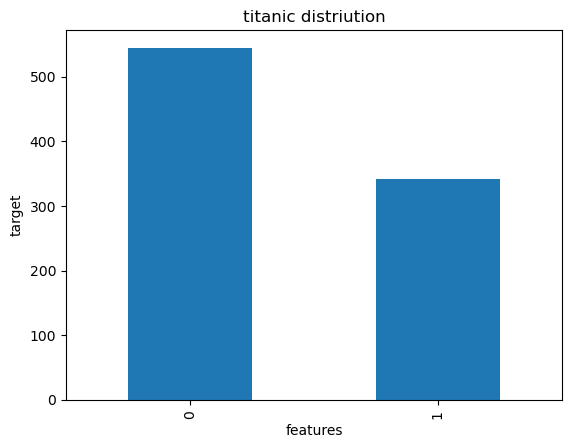

In [16]:
titanic["Survived"].value_counts().plot(kind = "bar")
plt.title("titanic distriution")
plt.xlabel("features")
plt.ylabel("target")
plt.show()

In [17]:
features= ['Pclass', 'Sex', 'Age', 'SibSp', 'PaCh', 'Fare']

target = 'Survived'
X=titanic[features].copy()
y= titanic["Survived"].copy()

In [18]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [19]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [20]:
X["Sex"]=X["Sex"].apply(lambda x: 1 if x == "female" else 0)

In [21]:
X

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...
882,2,0,27.0,0,0,13.0000
883,1,1,19.0,0,0,30.0000
884,3,1,7.0,1,2,23.4500
885,1,0,26.0,0,0,30.0000


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify = y)

In [23]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (709, 6)
X_test: (178, 6)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
model_prediction = logistic_model.predict(X_test_scaled)

model_accuracy= accuracy_score(
    y_test,
    model_prediction
)
print("Logistic Regression:", model_accuracy)

Logistic Regression: 0.7696629213483146


In [27]:
print(classification_report(y_test, model_prediction))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       109
           1       0.71      0.68      0.70        69

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.76       178
weighted avg       0.77      0.77      0.77       178



## DECISION TREE MODEL

In [28]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state = 42)
tree_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
tree_prediction = tree_model.predict(X_test_scaled)
tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)
print("Decision Tree:", tree_accuracy)

Decision Tree: 0.8033707865168539


In [30]:
print(classification_report(y_test, tree_prediction))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       109
           1       0.79      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178



## RANDOM FOREST CLASSIFIER

In [31]:
random_model = RandomForestClassifier(max_depth = 5, random_state = 42, n_estimators = 150)
random_model.fit(X_train_scaled, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
random_prediction = random_model.predict(X_test_scaled)
random_accuracy = accuracy_score(
    y_test,
    random_prediction
)
print("RandomForestClassifier:", random_accuracy)

RandomForestClassifier: 0.7921348314606742


In [33]:
print(classification_report(y_test, random_prediction))

              precision    recall  f1-score   support

           0       0.79      0.91      0.84       109
           1       0.81      0.61      0.69        69

    accuracy                           0.79       178
   macro avg       0.80      0.76      0.77       178
weighted avg       0.79      0.79      0.79       178



In [34]:
result = pd.DataFrame({
    "Model":[
    "logistic_model",
    "tree_model",
    "forest_model"
    ],
    "accuracy": [
        model_accuracy,
        tree_accuracy,
        random_accuracy
    ]
})
result

,Model,accuracy
0,logistic_model,0.769663
1,tree_model,0.803371
2,forest_model,0.792135


## Using GRIDSEARCHCV ON RANDOM FOREST CLASSIFIER

In [36]:
#Tuning my model
forest_params = {
 "n_estimators": [50, 100, 200],
 "max_depth": [3, 5, 7, 10]
}
forest_grid = GridSearchCV(
 RandomForestClassifier(random_state=42),
 forest_params,
 cv=5,
 scoring="accuracy"
)
forest_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


# To get the best score

In [37]:
print("Best Parameters:")
print(forest_grid.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(forest_grid.best_score_)

Best Parameters:
{'max_depth': 7, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.8392168614524025


## Model_Prediction

In [39]:
best_forest = forest_grid.best_estimator_
tuned_forest_predictions = best_forest.predict(X_test)
tuned_forest_accuracy = accuracy_score(
 y_test,
 tuned_forest_predictions
)
print(
 "Tuned Random Forest Accuracy:",
 tuned_forest_accuracy
)

Tuned Random Forest Accuracy: 0.797752808988764


In [40]:
print(classification_report(y_test, tuned_forest_predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       109
           1       0.78      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.79      0.77      0.78       178
weighted avg       0.80      0.80      0.79       178



In [41]:
def predict_survival(name, Pclass, Sex, Age, SibSp, PaCh, Fare):
 """
 Predict survival using our model
 """
 input_data = pd.DataFrame({
 'Pclass': [Pclass],
 'Sex': [Sex],
 'Age': [Age],
 'SibSp': [SibSp],
 'PaCh': [PaCh],
 'Fare': [Fare]
 })

 prediction = best_forest.predict(input_data)[0]
 probabilities = best_forest.predict_proba(input_data)[0] # to explain
 if prediction == 0:
     result = f'Wooo 😮 {name.title()}, you Died 😢 '
 else:
     result = f'Cheers 🥂 {name.title()}, you Survived 😁 '

 return result, probabilities

In [43]:
print(predict_survival('Abiola', Pclass=3, Sex=1, Age=25.0, SibSp=0, PaCh=0,Fare=100))

('Cheers 🥂 Abiola, you Survived 😁 ', array([0.37671003, 0.62328997]))
